# Day 5: Regression Evaluation

**Theme:** Evaluate the Day 4 linear regression model on held-out Gaia stars.

Today we will:

- load the Day 4 test-set predictions
- define `y_test` and `y_pred`
- compute mean absolute error, root mean squared error, and R-squared
- compute residuals as `y_test - y_pred`
- plot actual versus predicted `abs_g_mag`
- plot predicted values versus residuals with a zero-residual reference line
- plot a residual histogram
- compare residual behavior for bright and faint stars
- save Day 5 metrics and residuals for final interpretation

Model quality must be assessed on held-out data, not only on training performance. The Day 4 model learned from the training split, so Day 5 focuses on the test split: stars the model did not use while fitting coefficients.


## 1. Imports

`sklearn.metrics` gives us standard regression scores. We compute RMSE from MSE with `np.sqrt(...)` so the error is in the same unit as `abs_g_mag`.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", None)


## 2. Load Day 4 Held-Out Predictions

Day 5 evaluates the predictions saved by Day 4. If this file is missing, run `day_04_train_linear_regression.ipynb` first so the train/test split and predictions are created in one place.


In [2]:
prediction_candidates = [
    Path("../data/processed/gaia_day4_linear_regression_predictions.csv"),
    Path("data/processed/gaia_day4_linear_regression_predictions.csv"),
    Path("gaia-explorer/data/processed/gaia_day4_linear_regression_predictions.csv"),
]
coefficient_candidates = [
    Path("../data/processed/gaia_day4_linear_regression_coefficients.csv"),
    Path("data/processed/gaia_day4_linear_regression_coefficients.csv"),
    Path("gaia-explorer/data/processed/gaia_day4_linear_regression_coefficients.csv"),
]

PREDICTION_PATH = next((path for path in prediction_candidates if path.exists()), None)
COEFFICIENT_PATH = next((path for path in coefficient_candidates if path.exists()), None)

if PREDICTION_PATH is None:
    searched = "\n".join(str(path) for path in prediction_candidates)
    raise FileNotFoundError(
        "Could not find Day 4 predictions. Run day_04_train_linear_regression.ipynb first.\n"
        f"Searched:\n{searched}"
    )

predictions_df = pd.read_csv(PREDICTION_PATH)
print(f"Loaded Day 4 predictions from: {PREDICTION_PATH}")
print("Prediction rows:", len(predictions_df))

if COEFFICIENT_PATH is not None:
    coefficient_table = pd.read_csv(COEFFICIENT_PATH)
    print(f"Loaded Day 4 coefficients from: {COEFFICIENT_PATH}")
else:
    coefficient_table = pd.DataFrame()
    print("Day 4 coefficient file was not found; continuing with predictions only.")

predictions_df.head()


Loaded Day 4 predictions from: ../data/processed/gaia_day4_linear_regression_predictions.csv
Prediction rows: 483
Loaded Day 4 coefficients from: ../data/processed/gaia_day4_linear_regression_coefficients.csv


,source_id,parallax_snr,actual_abs_g_mag,predicted_abs_g_mag,residual,bp_rp,ra,dec
0,140363005863333888,22.676214,2.360272,5.245278,-2.885005,1.232842,44.883762,35.709453
1,139223495204510592,5.819606,6.663259,5.459992,1.203267,1.322294,48.486009,37.050985
2,137352882328671744,34.451136,11.537503,11.299972,0.237531,3.015198,45.027974,35.465866
3,139432509788720128,86.951835,7.640880,7.081991,0.558889,1.748700,46.648083,37.333840
4,139409866721170560,59.667212,0.384979,5.483155,-5.098176,1.298270,46.989462,37.048984


## 3. Confirm Evaluation Columns

The required Day 5 columns are:

- `actual_abs_g_mag`: true held-out target value, equivalent to `y_test`
- `predicted_abs_g_mag`: model output for the held-out row, equivalent to `y_pred`
- `residual`: `actual - predicted`

A positive residual means the real star is fainter than predicted. A negative residual means the real star is brighter than predicted.


In [3]:
required_columns = [
    "source_id",
    "actual_abs_g_mag",
    "predicted_abs_g_mag",
    "bp_rp",
    "ra",
    "dec",
    "parallax_snr",
]

missing_required_columns = [col for col in required_columns if col not in predictions_df.columns]

if missing_required_columns:
    raise ValueError(f"Missing required columns: {missing_required_columns}")

# Use the standard evaluation names from ML notation.
y_test = predictions_df["actual_abs_g_mag"]
y_pred = predictions_df["predicted_abs_g_mag"]

# Residuals are actual minus predicted, as required by the Day 5 spec.
predictions_df["residual"] = y_test - y_pred
residuals = predictions_df["residual"]

predictions_df[["source_id", "actual_abs_g_mag", "predicted_abs_g_mag", "residual", "bp_rp", "parallax_snr"]].head()


,source_id,actual_abs_g_mag,predicted_abs_g_mag,residual,bp_rp,parallax_snr
0,140363005863333888,2.360272,5.245278,-2.885005,1.232842,22.676214
1,139223495204510592,6.663259,5.459992,1.203267,1.322294,5.819606
2,137352882328671744,11.537503,11.299972,0.237531,3.015198,34.451136
3,139432509788720128,7.640880,7.081991,0.558889,1.748700,86.951835
4,139409866721170560,0.384979,5.483155,-5.098176,1.298270,59.667212


## 4. Compute Evaluation Metrics

Three standard regression metrics tell us different things:

- **MAE**: average absolute error in magnitudes. Easy to interpret.
- **RMSE**: like MAE, but it punishes large errors more strongly.
- **R-squared**: fraction of target variance explained by the model. `1.0` is perfect; values near `0` mean weak explanatory power.

All metrics are computed on held-out test rows.


In [4]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

metrics_table = pd.DataFrame(
    [
        {
            "metric": "MAE",
            "value": mae,
            "interpretation": "Average absolute prediction error in abs_g_mag units.",
        },
        {
            "metric": "RMSE",
            "value": rmse,
            "interpretation": "Error in abs_g_mag units, with larger errors penalized more heavily.",
        },
        {
            "metric": "R-squared",
            "value": r2,
            "interpretation": "Share of held-out abs_g_mag variance explained by the model.",
        },
    ]
)

metrics_table


,metric,value,interpretation
0,MAE,0.839228,Average absolute prediction error in abs_g_mag...
1,RMSE,1.442826,"Error in abs_g_mag units, with larger errors p..."
2,R-squared,0.689681,Share of held-out abs_g_mag variance explained...


## 5. Actual Versus Predicted Plot

A perfect model would place all points on the diagonal reference line. Points far from the line are poor predictions.

Because magnitude is inverted, smaller `abs_g_mag` values are brighter and larger values are fainter. This plot keeps the normal numeric axes so the diagonal comparison is easier to read.


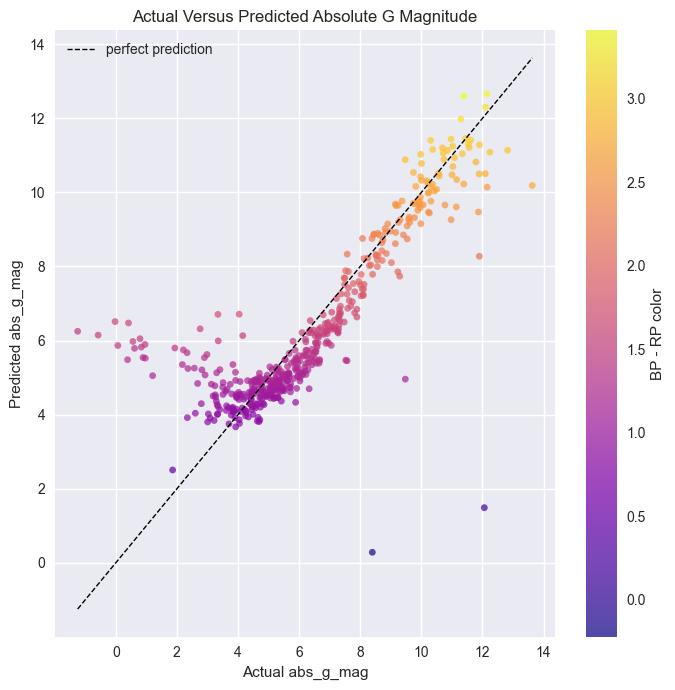

In [5]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(
    y_test,
    y_pred,
    c=predictions_df["bp_rp"],
    cmap="plasma",
    s=24,
    alpha=0.70,
    linewidths=0,
)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())
ax.plot([min_value, max_value], [min_value, max_value], color="black", linestyle="--", linewidth=1, label="perfect prediction")

ax.set_title("Actual Versus Predicted Absolute G Magnitude")
ax.set_xlabel("Actual abs_g_mag")
ax.set_ylabel("Predicted abs_g_mag")
ax.legend()

colorbar = plt.colorbar(ax.collections[0], ax=ax)
colorbar.set_label("BP - RP color")

plt.tight_layout()
plt.show()


## 6. Predicted Values Versus Residuals

Residuals show where the model is wrong:

```text
residual = actual_abs_g_mag - predicted_abs_g_mag
```

- Residual near `0`: good prediction
- Positive residual: actual star is fainter than predicted
- Negative residual: actual star is brighter than predicted

A good residual plot should look roughly centered around the zero line without a strong curve or funnel shape. Structure in this plot suggests the linear model is missing real patterns.


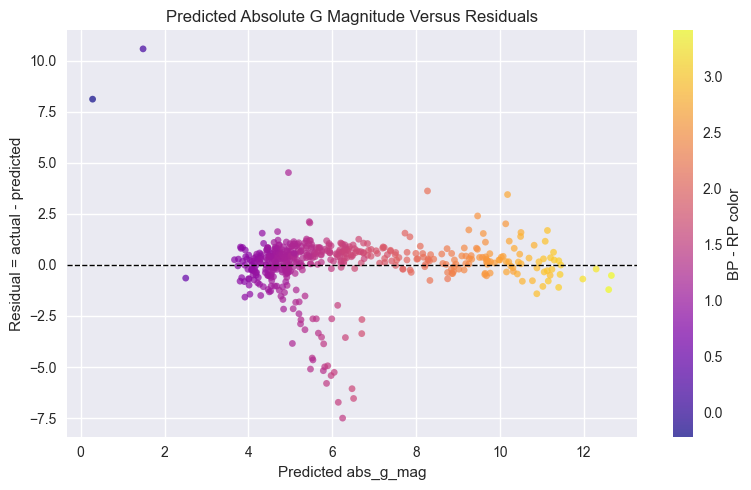

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    y_pred,
    residuals,
    c=predictions_df["bp_rp"],
    cmap="plasma",
    s=24,
    alpha=0.70,
    linewidths=0,
)

ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Predicted Absolute G Magnitude Versus Residuals")
ax.set_xlabel("Predicted abs_g_mag")
ax.set_ylabel("Residual = actual - predicted")

colorbar = plt.colorbar(ax.collections[0], ax=ax)
colorbar.set_label("BP - RP color")

plt.tight_layout()
plt.show()


## 7. Residual Histogram

The residual histogram shows whether errors are centered near zero and whether there are many large mistakes. A narrow histogram centered on zero is better. Wide tails mean the model makes some large errors.


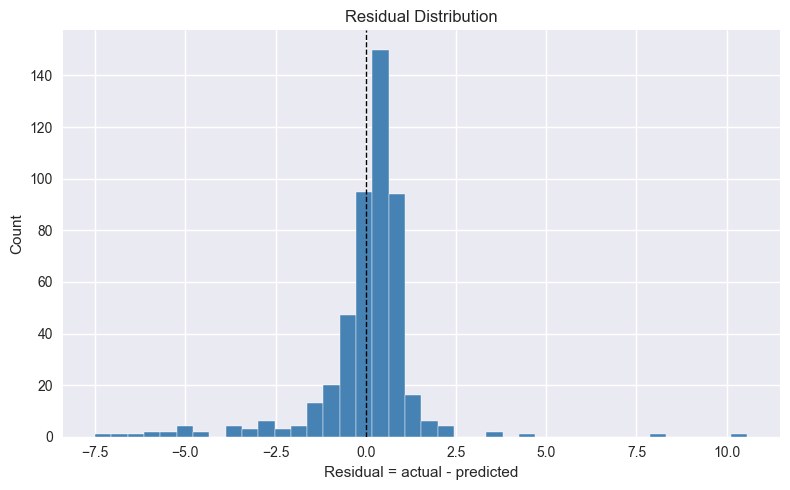

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(residuals, bins=40, color="steelblue", edgecolor="white")
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Residual Distribution")
ax.set_xlabel("Residual = actual - predicted")
ax.set_ylabel("Count")

plt.tight_layout()
plt.show()


## 8. Bright Versus Faint Error Check

This table compares prediction error sizes for brighter and fainter stars. It helps answer whether the model performs better in one brightness regime.

Important naming note:

- `abs_g_mag` means **absolute magnitude**: brightness corrected for distance.
- `.abs()` below means **absolute value** of the residual: error size, ignoring whether the model predicted too bright or too faint.

We do **not** take the absolute value of `actual_abs_g_mag` when assigning bright/faint groups. The grouping uses the original magnitude values, where lower `abs_g_mag` means brighter.


In [8]:
median_actual_abs_g_mag = y_test.median()

evaluation_df = predictions_df.copy()

# This is the absolute value of the prediction error, not absolute magnitude.
# residual = -3 and residual = +3 are both errors of size 3 magnitudes.
evaluation_df["prediction_error_size_mag"] = evaluation_df["residual"].abs()

# Bright/faint grouping uses the original actual_abs_g_mag values.
# Lower abs_g_mag means brighter, so values below the median go in the brighter half.
evaluation_df["brightness_group"] = np.where(
    evaluation_df["actual_abs_g_mag"] <= median_actual_abs_g_mag,
    "brighter half",
    "fainter half",
)

brightness_error_table = (
    evaluation_df
    .groupby("brightness_group")
    .agg(
        rows=("source_id", "count"),
        mean_actual_abs_g_mag=("actual_abs_g_mag", "mean"),
        mean_error_size_mag=("prediction_error_size_mag", "mean"),
        median_error_size_mag=("prediction_error_size_mag", "median"),
        max_error_size_mag=("prediction_error_size_mag", "max"),
    )
    .reset_index()
)

brightness_error_table


,brightness_group,rows,mean_actual_abs_g_mag,mean_error_size_mag,median_error_size_mag,max_error_size_mag
0,brighter half,242,4.273881,0.945774,0.472803,7.498153
1,fainter half,241,8.343776,0.732240,0.561330,10.572766


## 9. Largest Residual Examples

Large residuals are the most useful rows to inspect before Day 7. They may point to stellar populations that a simple linear model cannot capture, such as giants, white dwarfs, very red stars, or bright outliers.


In [9]:
high_residual_examples = evaluation_df.sort_values("prediction_error_size_mag", ascending=False).head(10)
high_residual_examples[
    [
        "source_id",
        "bp_rp",
        "parallax_snr",
        "actual_abs_g_mag",
        "predicted_abs_g_mag",
        "residual",
        "prediction_error_size_mag",
    ]
]


,source_id,bp_rp,parallax_snr,actual_abs_g_mag,predicted_abs_g_mag,residual,prediction_error_size_mag
112,139254388905996032,0.159437,13.347744,12.060765,1.487999,10.572766,10.572766
461,139484629215390464,-0.219013,6.473233,8.395272,0.283622,8.111650,8.111650
314,141420117574894080,1.434080,11.618137,-1.248268,6.249885,-7.498153,7.498153
279,138907011949915008,1.490329,11.185368,-0.577621,6.146684,-6.724305,6.724305
418,139004318728815104,1.593946,18.325787,-0.024381,6.511745,-6.536126,6.536126
15,139366882688665728,1.601420,7.194200,0.415702,6.474579,-6.058877,6.058877
379,138840594575909632,1.434197,6.478127,0.067361,5.866158,-5.798797,5.798797
187,138947728239998976,1.466312,6.109878,0.559912,5.975286,-5.415373,5.415373
209,139149209450248832,1.488963,149.388075,0.791668,6.049531,-5.257864,5.257864
371,141360262910325888,1.312448,17.987554,0.613111,5.789633,-5.176522,5.176522


## 10. Save Day 5 Evaluation Outputs

These files let Day 7 interpret model behavior without recomputing metrics.


In [10]:
metrics_output_candidates = [
    Path("../data/processed/gaia_day5_evaluation_metrics.csv"),
    Path("data/processed/gaia_day5_evaluation_metrics.csv"),
    Path("gaia-explorer/data/processed/gaia_day5_evaluation_metrics.csv"),
]
residual_output_candidates = [
    Path("../data/processed/gaia_day5_evaluation_residuals.csv"),
    Path("data/processed/gaia_day5_evaluation_residuals.csv"),
    Path("gaia-explorer/data/processed/gaia_day5_evaluation_residuals.csv"),
]

METRICS_OUTPUT_PATH = next(
    (path for path in metrics_output_candidates if path.parent.exists()),
    metrics_output_candidates[0],
)
RESIDUAL_OUTPUT_PATH = next(
    (path for path in residual_output_candidates if path.parent.exists()),
    residual_output_candidates[0],
)

METRICS_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
RESIDUAL_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

metrics_table.to_csv(METRICS_OUTPUT_PATH, index=False)
evaluation_df.to_csv(RESIDUAL_OUTPUT_PATH, index=False)

print(f"Saved Day 5 metrics to: {METRICS_OUTPUT_PATH}")
print(f"Saved Day 5 residuals to: {RESIDUAL_OUTPUT_PATH}")
print("Residual rows:", len(evaluation_df))


Saved Day 5 metrics to: ../data/processed/gaia_day5_evaluation_metrics.csv
Saved Day 5 residuals to: ../data/processed/gaia_day5_evaluation_residuals.csv
Residual rows: 483


## Reflection Questions And Starter Answers

1. Does the model perform better for bright stars or faint stars?

   **Starter answer:** Compare the bright-versus-faint error table. The group with the lower mean absolute error is where the model performs better. If bright stars have larger errors, it may be because bright evolved stars do not follow the same simple color-brightness line as main-sequence stars.

2. Do the residuals look randomly scattered or structured?

   **Starter answer:** If residuals form a curve, funnel, or color-based pattern, they are structured. Structured residuals mean the simple linear model is missing something real in the data.

3. What does poor performance reveal about linear regression and stellar populations?

   **Starter answer:** A single straight-line model is too simple for the full color-magnitude diagram. Real Gaia stars include main-sequence stars, giants, white dwarfs, and noisy measurements, so one linear relationship cannot represent every population well.

4. Why is RMSE usually larger than MAE?

   **Starter answer:** RMSE squares errors before averaging, so a few large mistakes increase RMSE more strongly than MAE.

5. Why do we evaluate on held-out test data?

   **Starter answer:** Test data tells us how the model behaves on stars it did not train on. Training performance alone can make a model look better than it really is.
